Prediction approach: predict the next cluster use the trend of how the customer has moved in the past.

In [8]:
import pandas as pd
import os
import pickle
import skfuzzy as fuzz
import numpy as np
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, classification_report, accuracy_score
from sklearn.ensemble import VotingClassifier
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
cluster_reverse_mapping =joblib.load('../models/fuzzy_cmeans_model.pkl')['cluster_names']
cluster_mapping = {v: k for k, v in cluster_reverse_mapping.items()}

In [10]:
# predicts the cluster for a dataframe
def predict_clusters(df_all_features,features_path = '../data/features_with_weights.csv', model_file='../models/fuzzy_cmeans_model.pkl'):
    features_df = pd.read_csv(features_path)
    feature_columns = features_df['Feature'].to_list()
    weights = features_df['FinalWeight'].to_list()
    # features used by segmentation model
    # feature_columns = json.load(open('../data/cleaned/top_features.json'))
    # scale features for prediction model
    df = df_all_features[feature_columns]
    standardScaler = StandardScaler()
    normalizedFeatures = standardScaler.fit_transform(df)
    #weights = [1,0.57821138, 0.10583493, 0.07332408, 0.07208094, 0.04819159,
    #0.01809966, 0.04088511, 0.03574647, 0.01459683, 0.01302901] # values from testing
    weightedFeatures = normalizedFeatures * weights

    # Load the saved model
    fuzzy_cmeans_model = joblib.load(model_file)
    centers = fuzzy_cmeans_model['centers']
    mapping = fuzzy_cmeans_model['mapping']
    cluster_names = fuzzy_cmeans_model['cluster_names']
    u_pred, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            weightedFeatures.T, centers, fuzzy_cmeans_model['fuzziness_parameter'], 
            error=0.005, maxiter=1000
        )
    # Get hard cluster assignments
    hard_labels_pred = np.argmax(u_pred, axis=0)

    # Apply the saved mapping
    renumbered_labels_pred = mapping[hard_labels_pred]

    # Convert to cluster names
    named_labels_pred = np.vectorize(cluster_names.get)(renumbered_labels_pred)
    # memebership_degree = u_pred
    return pd.Series(named_labels_pred)
    


In [11]:
def add_cluster_prediction(df_all_features,features_path = '../data/features_with_weights.csv', model_file='../models/fuzzy_cmeans_model.pkl'):
    cluster_predictions = predict_clusters(df_all_features,features_path, model_file)
    df_all_features['cluster_prediction'] = cluster_predictions
    return df_all_features

In [14]:
file = "../data/cleaned/monthlydata/2022_1_data.csv"
data = pd.read_csv(file)
unique_customers = data["CustomerName"].unique()

# Creating customer specific time series

In [15]:
def get_customer_data_as_time_series(customer_name, input_dir = "../data/cleaned/monthlymetrics"):
    df_for_customer = pd.DataFrame(columns=['CustomerName', 'TotalRevenue', 'TotalProfit', 'TotalUnitPrice',
       'TotalSalesQty', 'OrderCount', 'NumDistinctProducts',
       'NumDistinctProductGroups', 'BranchCount', 'TopProductID',
       'TopProductGroupID', 'ProductDiversityIndex',
       'ProductConcentrationIndex', 'TopProductRevenueShare',
       'TopProductGroupRevenueShare', 'CustomerLifetimeDays', 'AvgOrderValue',
       'RepeatPurchaseRatio', 'HighProfitProductShare', 'PopularProductShare',
       'HighProfitOrderRatio', 'PopularOrderRatio', 'Year', 'Month'])

    for file in sorted(os.listdir(input_dir)):  # Sort files to ensure order
        if file.endswith(".csv"):
            file_path = os.path.join(input_dir, file)
            data = pd.read_csv(file_path)

            # Extract year and month from the filename
            data["Year"] = file[17:21]
            data["Month"] = file[22:24]

            # Filter for the specific customer
            customer_data = data[data['CustomerName'] == customer_name]

            # Concatenate the result
            df_for_customer = pd.concat([df_for_customer, customer_data], ignore_index=True)
    return df_for_customer


In [16]:
# the following code is used to create the time series data for each customer (customer_data_time_series.pkl)
"""
customers_dataframes = {}

for customer in unique_customers:
    customers_dataframes[customer] = get_customer_data_as_time_series(customer)
# saving the customer dataframes to a pickle file to avoid recomputing the time series data
with open('../data/cleaned/customer_data_time_series.pkl', 'wb') as f:
    pickle.dump(customers_dataframes, f)
"""

"\ncustomers_dataframes = {}\n\nfor customer in unique_customers:\n    customers_dataframes[customer] = get_customer_data_as_time_series(customer)\n# saving the customer dataframes to a pickle file to avoid recomputing the time series data\nwith open('../data/cleaned/customer_data_time_series.pkl', 'wb') as f:\n    pickle.dump(customers_dataframes, f)\n"

In [17]:
# load the customer dataframes from the pickle file
with open('../data/cleaned/customer_data_time_series.pkl', 'rb') as f:
    customers_dataframes = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../data/cleaned/customer_data_time_series.pkl'

In [ ]:
combined_df = pd.DataFrame()
for customer, df in customers_dataframes.items():
    # Add the customer name to the dataframe
    df['CustomerName'] = customer
    # Append the dataframe to the combined dataframe
    combined_df = pd.concat([combined_df, df], ignore_index=True)    

In [ ]:
add_cluster_prediction(combined_df)

,CustomerName,TotalRevenue,TotalProfit,TotalUnitPrice,TotalSalesQty,OrderCount,NumDistinctProducts,NumDistinctProductGroups,BranchCount,TopProductID,...,CustomerLifetimeDays,AvgOrderValue,RepeatPurchaseRatio,HighProfitProductShare,PopularProductShare,HighProfitOrderRatio,PopularOrderRatio,Year,Month,cluster_prediction
0,ADAMS PLC AND SONS,8645.13,3680.91,343.211359,22052.0,12.0,29.0,10.0,1.0,PGO-856-PV3,...,27.0,720.427500,0.413793,0.157895,0.263158,6.0,10.0,2022,01,Bronze
1,ADAMS PLC AND SONS,6956.58,2660.24,353.780509,16696.0,10.0,38.0,10.0,1.0,OZW-556-BS7,...,19.0,695.658000,0.263158,0.080000,0.160000,4.0,8.0,2022,02,Bronze
2,ADAMS PLC AND SONS,22112.17,9981.44,3051.630219,63151.0,12.0,66.0,17.0,2.0,KOH-232-IO4,...,28.0,1842.680833,0.181818,0.154639,0.237113,15.0,23.0,2022,03,Bronze
3,ADAMS PLC AND SONS,15012.09,6389.46,1120.715073,33151.0,13.0,53.0,13.0,2.0,CCX-754-QX9,...,22.0,1154.776154,0.245283,0.164384,0.150685,12.0,11.0,2022,04,Bronze
4,ADAMS PLC AND SONS,5217.06,2278.15,124.382690,10204.0,10.0,14.0,8.0,2.0,JJQ-303-OR6,...,16.0,521.706000,0.714286,0.227273,0.181818,5.0,4.0,2022,05,Bronze
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24931,ZIMMERMAN-WISE PLC,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2023,08,Rock
24932,ZIMMERMAN-WISE PLC,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2023,09,Rock
24933,ZIMMERMAN-WISE PLC,972.96,447.84,30.603772,316.0,3.0,5.0,3.0,1.0,EAM-695-QN0,...,8.0,324.320000,0.600000,0.200000,0.000000,1.0,0.0,2023,10,Rock
24934,ZIMMERMAN-WISE PLC,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2023,11,Rock


In [ ]:
# Save the combined dataframe to a CSV file
combined_df.to_csv('../data/cleaned/customer_data_time_series.csv', index=False)


In [ ]:
prediction_data = combined_df[['CustomerName', 'cluster_prediction']]

In [ ]:
# Encode cluster_prediction
prediction_data['cluster_encoded'] = prediction_data['cluster_prediction'].map(cluster_mapping)

# Add a month index (grouped by customer)
prediction_data['month'] = prediction_data.groupby('CustomerName').cumcount()

# Pivot to wide format
wide_prediction_df = prediction_data.pivot(index='CustomerName', columns='month', values='cluster_encoded')

# Rename columns
wide_prediction_df.columns = [f'month_{i+1}' for i in wide_prediction_df.columns]
# Reset index
wide_prediction_df = wide_prediction_df.reset_index()

/var/folders/pf/rh7r7nr92zggr4t5dsl35h2m0000gn/T/ipykernel_1237/3259336979.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['cluster_encoded'] = prediction_data['cluster_prediction'].map(cluster_mapping)
/var/folders/pf/rh7r7nr92zggr4t5dsl35h2m0000gn/T/ipykernel_1237/3259336979.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['month'] = prediction_data.groupby('CustomerName').cumcount()


In [ ]:
# Extract features and target
X = wide_prediction_df[[f'month_{i}' for i in range(1, 24)]]
y = wide_prediction_df['month_24'].astype(int)

In [ ]:
X.columns

Index(['month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'month_13', 'month_14', 'month_15', 'month_16', 'month_17', 'month_18',
       'month_19', 'month_20', 'month_21', 'month_22', 'month_23'],
      dtype='object')

In [ ]:
# Count the class frequencies
class_counts = pd.Series(y).value_counts()
print("Class distribution in y:", class_counts)

# Identify rare classes (clusters with <2 occurrences)
rare_classes = class_counts[class_counts < 2].index
print("Rare classes to be excluded:", rare_classes)

# Filter out rare classes from the dataset
keep_mask = ~pd.Series(y).isin(rare_classes)
X_filtered = X[keep_mask]
y_filtered = y[keep_mask]

# Verify class distribution after filtering
print("Class distribution in y_filtered:", pd.Series(y_filtered).value_counts())

# Ensure rare but predictable classes (e.g., clusters 3 and 4 with <10 instances) are in both train and test
# Identify classes with low counts (e.g., >=2 and <10)
low_count_classes = class_counts[(class_counts >= 2) & (class_counts < 10)].index
print("Low-count classes to ensure in both sets:", low_count_classes)

# Split data into low-count and common classes
low_count_mask = pd.Series(y_filtered).isin(low_count_classes)
X_low_count = X_filtered[low_count_mask]
y_low_count = y_filtered[low_count_mask]
X_common = X_filtered[~low_count_mask]
y_common = y_filtered[~low_count_mask]

# Stratified split on common data
if len(X_common) > 0:  # Check if there's common data
    X_train_common, X_test_common, y_train_common, y_test_common = train_test_split(
        X_common, y_common, test_size=0.2, random_state=42, stratify=y_common
    )
else:
    # If no common data, initialize empty arrays
    X_train_common, X_test_common = pd.DataFrame(), pd.DataFrame()
    y_train_common, y_test_common = pd.Series(dtype='int64'), pd.Series(dtype='int64')

# Ensure at least one instance of each low-count class in both train and test
X_train_low = []
y_train_low = []
X_test_low = []
y_test_low = []

for cls in low_count_classes:
    cls_mask = y_low_count == cls
    X_cls = X_low_count[cls_mask]
    y_cls = y_low_count[cls_mask]
    
    # If class has exactly 2 instances, put one in train and one in test
    if len(X_cls) == 2:
        X_train_low.append(X_cls.iloc[[0]])
        y_train_low.append(y_cls.iloc[[0]])
        X_test_low.append(X_cls.iloc[[1]])
        y_test_low.append(y_cls.iloc[[1]])
    else:
        # For classes with more than 2 instances, split normally
        X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
            X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls
        )
        X_train_low.append(X_train_cls)
        y_train_low.append(y_train_cls)
        X_test_low.append(X_test_cls)
        y_test_low.append(y_test_cls)

# Combine common and low-count data
X_train = pd.concat([X_train_common] + X_train_low) if len(X_train_low) > 0 else X_train_common
y_train = pd.concat([y_train_common] + y_train_low) if len(y_train_low) > 0 else y_train_common
X_test = pd.concat([X_test_common] + X_test_low) if len(X_test_low) > 0 else X_test_common
y_test = pd.concat([y_test_common] + y_test_low) if len(y_test_low) > 0 else y_test_common

# Verify class distribution in train and test sets
print("Class distribution in y_train:", pd.Series(y_train).value_counts())
print("Class distribution in y_test:", pd.Series(y_test).value_counts())

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=6, weights='distance'),
}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Get unique classes in y_test for the classification report
    unique_classes = sorted(set(y_test))
    target_names = [cluster_reverse_mapping[i] for i in unique_classes]
    
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(
        y_test, y_pred, 
        target_names=target_names, 
        zero_division=0
    ))

Class distribution in y: month_24
0    954
1     63
2     14
3      5
4      2
5      1
Name: count, dtype: int64
Rare classes to be excluded: Index([5], dtype='int64', name='month_24')
Class distribution in y_filtered: month_24
0    954
1     63
2     14
3      5
4      2
Name: count, dtype: int64
Low-count classes to ensure in both sets: Index([3, 4], dtype='int64', name='month_24')
Class distribution in y_train: month_24
0    763
1     50
2     11
3      3
4      1
Name: count, dtype: int64
Class distribution in y_test: month_24
0    191
1     13
2      3
3      2
4      1
Name: count, dtype: int64

Random Forest Performance:
Accuracy: 0.9666666666666667
Classification Report:
               precision    recall  f1-score   support

        Rock       0.97      1.00      0.99       191
      Bronze       1.00      0.62      0.76        13
      Silver       0.50      0.33      0.40         3
        Gold       0.67      1.00      0.80         2
     Diamond       1.00      1.00      

In [ ]:
X_train

,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23
447,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
862,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
969,5,5,5,5,4,4,5,5,3,3,...,5,5,5,5,5,5,5,3,3,3
569,3,3,3,3,3,4,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
470,3,3,4,4,3,3,3,4,3,3,...,3,4,3,3,3,3,3,5,0,1


In [ ]:
# # Count the class frequencies
# class_counts = y.value_counts()

# # Identify rare classes (you can change the threshold if needed)
# rare_classes = class_counts[class_counts < 2].index

# # Split the data into rare and common class data
# rare_mask = y.isin(rare_classes)
# common_mask = ~rare_mask

# X_rare = X[rare_mask]
# y_rare = y[rare_mask]

# X_common = X[common_mask]
# y_common = y[common_mask]

# # Stratified split on common data
# X_train_common, X_test_common, y_train_common, y_test_common = train_test_split(
#     X_common, y_common, test_size=0.2, random_state=42, stratify=y_common
# )

# # Add rare class data to the training set
# X_train = pd.concat([X_train_common, X_rare])
# y_train = pd.concat([y_train_common, y_rare])

# """only clusters that exist only once in the data are part of both test and train data"""

# # Add rare class data to the test set
# X_test = pd.concat([X_test_common, X_rare])
# y_test = pd.concat([y_test_common, y_rare])

In [ ]:
# """LightGBM(Light Gradient Boosting Machine) is a fast, gradient boosting model optimized for performance on tabular data. 
# We used it with class weighting to address data imbalance, and it offered complementary strengths to Random Forest, 
# particularly in identifying minority class patterns."""

# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
#     "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "KNN": KNeighborsClassifier(n_neighbors=6),
# }

# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
    
#     print(f"\n{name} Performance:")
#     print("Accuracy:", accuracy_score(y_test, y_pred))
#     print("Classification Report:\n", classification_report(y_test, y_pred, target_names=[cluster_reverse_mapping[i] for i in sorted(set(y))]))

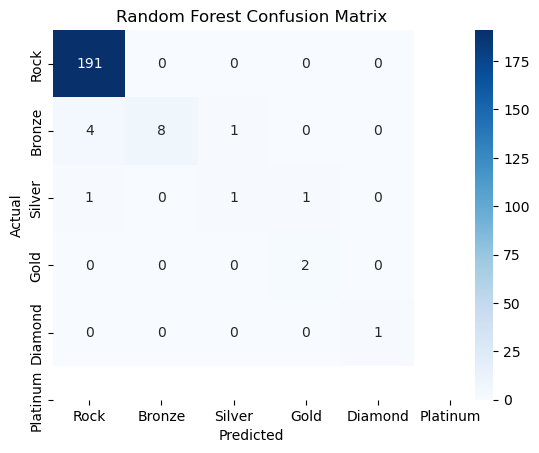

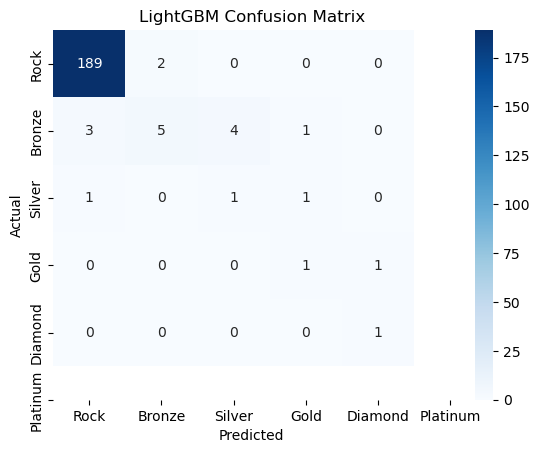

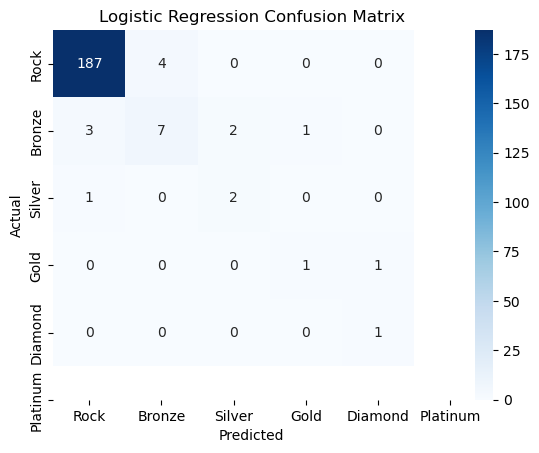

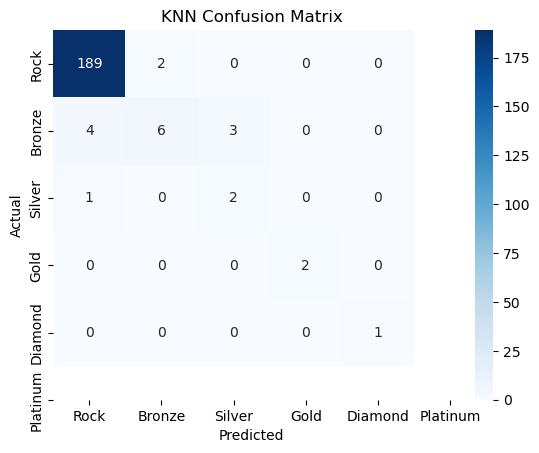

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[cluster_reverse_mapping[i] for i in sorted(set(y))],
                yticklabels=[cluster_reverse_mapping[i] for i in sorted(set(y))])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

for name, model in models.items():
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, f"{name} Confusion Matrix")

"While the model performs well overall (93% accuracy), its performance on underrepresented classes such as 'Gold' and 'Diamond' is limited due to class imbalance. Future work could involve data augmentation, synthetic oversampling (e.g., SMOTE), or reclassification strategies to address this."

We combined Random Forest and LightGBM in a soft voting ensemble to leverage their complementary strengths: Random Forest’s overall stability and LightGBM’s sensitivity to minority classes. This strategy improved generalization, handled class imbalance more effectively, and resulted in a high-performing, balanced model suitable for deployment with awareness of its limitations on extremely rare classes.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
lgb_model = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

# Create the ensemble with soft voting
ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('lgbm', lgb_model)],
    voting='soft'
)

# Fit on training data
ensemble.fit(X_train, y_train)

# Predict on test data
y_pred_ensemble = ensemble.predict(X_test)

# Evaluate performance
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
# Get the actual labels present in y_test
labels_present = sorted(unique_labels(y_test, y_pred_ensemble))

# Map to cluster names
target_names_present = [cluster_reverse_mapping[i] for i in labels_present]

# Now create the report with explicit labels
ensemble_report = classification_report(
    y_test,
    y_pred_ensemble,
    labels=labels_present,
    target_names=target_names_present
)

print("Voting Ensemble Performance:")
print("Accuracy:", ensemble_accuracy)
print("Classification Report:\n", ensemble_report)


Voting Ensemble Performance:
Accuracy: 0.9380952380952381
Classification Report:
               precision    recall  f1-score   support

        Rock       0.98      0.99      0.98       191
      Bronze       0.71      0.38      0.50        13
      Silver       0.17      0.33      0.22         3
        Gold       0.50      0.50      0.50         2
     Diamond       0.50      1.00      0.67         1

    accuracy                           0.94       210
   macro avg       0.57      0.64      0.57       210
weighted avg       0.94      0.94      0.94       210



In [ ]:
# Predict the next month's clusters
wide_prediction_df['predicted_month_24'] = ensemble.predict(X)

# Save the updated dataframe to a CSV file
wide_prediction_df.to_csv('../data/cleaned/monthly_clusters_predictions_2022-2023.csv', index=False)

In [ ]:
wide_prediction_df['month_23'].value_counts()

month_23
0    941
1     77
2     12
3      6
4      2
5      1
Name: count, dtype: int64

In [ ]:
wide_prediction_df['month_24'].value_counts()

month_24
0    954
1     63
2     14
3      5
4      2
5      1
Name: count, dtype: int64

In [ ]:

wide_prediction_df['predicted_month_24'].value_counts()

predicted_month_24
0    953
1     60
2     17
3      5
4      4
Name: count, dtype: int64

In [ ]:
accuracy = (wide_prediction_df['month_24'] == wide_prediction_df['predicted_month_24']).mean()
print(f"Accuracy: {accuracy:.2%}")


Accuracy: 98.17%


In [ ]:
wide_prediction_df['error_distance'] = abs(wide_prediction_df['month_24'] - wide_prediction_df['predicted_month_24'])
mean_error = wide_prediction_df['error_distance'].mean()
print(f"Average cluster error distance: {mean_error:.2f}")


Average cluster error distance: 0.02


In [ ]:
joblib.dump(ensemble, '../models/voting_ensemble_model.pkl')

['../models/voting_ensemble_model.pkl']

# Testing model on 2024 data